In [1]:
from matplotlib.pyplot import *
import numpy as np
import healpy as hp
import sys
import os
import pickle
import tqdm
# from cmblensplus/wrap/
import curvedsky as cs
# from cmblensplus/utils/
import binning
import constant
import cmb
import misctools
import quad_func
# local
from dell.utils import camb_clfile

### setup parameters

In [2]:
# multipole range
Lmax  = 1024       # maximum multipole of output normalization
rlmin, rlmax = 100, 1024  # CMB multipole range for reconstruction
# instrument setup
sigP = 3. # uK-arcmin
theta = 30. #arcmin
# for sim
snmin = 1
snmax = 100
nside = 512
ow = True

In [3]:
L = np.linspace(0,Lmax,Lmax+1)
kfac = L*(L+1.)/2.
Lfac = kfac**2
rlzs = np.linspace(snmin,snmax,snmax-snmin+1,dtype=int)
ids = [str(i).zfill(4) for i in range(-1,1000)]
ids[0] = 'real'  # change 1st index

### setup filenames

In [4]:
indir = '/project/projectdirs/litebird/simulations/maps/lensing_project_paper/S4BIRD/'

In [5]:
f_cmb_map = {}
f_cmb_map['v'] = [ indir+'CMB_Lensed_Maps/CMB/cmb_sims_'+x+'.fits' for x in ids ]
f_cmb_map['c'] = [ indir+'CMB_Lensed_Maps_c/CMB/cmb_sims_'+x+'.fits' for x in ids ]
f_phi_map = [ indir+'CMB_Lensed_Maps/MASS/phi_sims_'+x+'.fits' for x in ids ]

In [6]:
oudir = '/global/homes/t/toshiyan/scratch/test/'

In [7]:
# example setup of filename and its ids
falm = {}
falm['v'] = { m: [oudir+'cmb/test_'+m+'_v_'+x+'.pkl' for x in ids] for m in ['E','B'] }
falm['c'] = { m: [oudir+'cmb/test_'+m+'_c_'+x+'.pkl' for x in ids] for m in ['E','B'] }
fklm = [oudir+'cmb/test_klm_'+x+'.pkl' for x in ids]

### prepare lensed, noise, and observed Cls

In [8]:
ucl_read = camb_clfile(indir+"CAMB/BBSims_lenspotential.dat",lmax=rlmax)
lcl_read = camb_clfile(indir+"CAMB/BBSims_lensed_dls.dat",lmax=rlmax)
for k in ucl_read.keys():
    if k in ['pp']: continue
    ucl_read[k] /= constant.Tcmb**2
for k in lcl_read.keys():
    lcl_read[k] /= constant.Tcmb**2

In [9]:
ucl = np.zeros((4,rlmax+1))
lcl = np.zeros((4,rlmax+1))
for i, k in enumerate(['tt','ee','bb','te']):
    ucl[i] = ucl_read[k]
    lcl[i] = lcl_read[k]    

In [10]:
ncl = (sigP*constant.ac2rad/constant.Tcmb)**2 * cmb.beam(theta,rlmax)**2

In [11]:
ocl = np.zeros((4,rlmax+1))
ocl[1,:] = lcl[1,:] + ncl
ocl[2,:] = lcl[2,:] + ncl

### prepare input kappa alm

In [12]:
for rlz in tqdm.tqdm(rlzs):
    if misctools.check_path(fklm[rlz],overwrite=ow): continue
    plm = hp.fitsfunc.read_alm(f_phi_map[rlz])
    phi = hp.sphtfunc.alm2map(plm, nside)
    klm = cs.utils.hp_map2alm(nside,Lmax,Lmax,phi) * kfac[:,None]
    pickle.dump((klm),open(fklm[rlz],"wb"),protocol=pickle.HIGHEST_PROTOCOL)

  0%|          | 0/100 [00:00<?, ?it/s]/global/homes/t/toshiyan/.conda/envs/loc/lib/python3.7/site-packages/healpy/sphtfunc.py:824: UserWarning: Sigma is 0.000000 arcmin (0.000000 rad) 
  sigma * 60 * 180 / np.pi, sigma
/global/homes/t/toshiyan/.conda/envs/loc/lib/python3.7/site-packages/healpy/sphtfunc.py:829: UserWarning: -> fwhm is 0.000000 arcmin
  sigma * 60 * 180 / np.pi * (2.0 * np.sqrt(2.0 * np.log(2.0)))
100%|██████████| 100/100 [09:49<00:00,  5.90s/it]


### prepare input CMB data

In [13]:
# generate CMB alms 
for rlz in tqdm.tqdm(rlzs):
    for k in ['v','c']:
        if misctools.check_path([falm[k]['E'][rlz],falm[k]['B'][rlz]],overwrite=ow): continue
        # read sim data
        Q, U = hp.fitsfunc.read_map(f_cmb_map[k][rlz],field=[1,2])
        NSIDE = hp.get_nside(Q)
        Ealm, Balm = cs.utils.hp_map2alm_spin(NSIDE,rlmax,rlmax,2,Q,U)/constant.Tcmb
        # add noise and filtering (temp)
        Ealm += cs.utils.gauss1alm(rlmax,ncl)
        Balm += cs.utils.gauss1alm(rlmax,ncl)
        pickle.dump((Ealm),open(falm[k]['E'][rlz],"wb"),protocol=pickle.HIGHEST_PROTOCOL)
        pickle.dump((Balm),open(falm[k]['B'][rlz],"wb"),protocol=pickle.HIGHEST_PROTOCOL)

  0%|          | 0/100 [00:00<?, ?it/s]/global/homes/t/toshiyan/.conda/envs/loc/lib/python3.7/site-packages/healpy/fitsfunc.py:391: UserWarning: NSIDE = 2048
  warnings.warn("NSIDE = {0:d}".format(nside))
/global/homes/t/toshiyan/.conda/envs/loc/lib/python3.7/site-packages/healpy/fitsfunc.py:400: UserWarning: ORDERING = RING in fits file
  warnings.warn("ORDERING = {0:s} in fits file".format(ordering))
/global/homes/t/toshiyan/.conda/envs/loc/lib/python3.7/site-packages/healpy/fitsfunc.py:428: UserWarning: INDXSCHM = IMPLICIT
  warnings.warn("INDXSCHM = {0:s}".format(schm))
100%|██████████| 100/100 [21:05<00:00, 12.66s/it]


### running reconstruction and N0, N1

In [15]:
qobj = {}
for k in ['v','c']:
    qobj[k] = quad_func.quad(root=oudir,rlz=rlzs,qtype='lens',stag=k,\
        lcl=lcl,ocl=ocl,ifl=ocl,falm=falm[k],olmax=Lmax,rlmin=rlmin,rlmax=rlmax,n0max=np.int(snmax/2),rdmax=snmax,nside=nside,qlist=['EB'],ids=ids,overwrite=ow)

/global/homes/t/toshiyan/.conda/envs/loc/lib/python3.7/site-packages/ipykernel_launcher.py:4: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  after removing the cwd from sys.path.


In [16]:
qobj['v'].qrec_flow(run=['norm','qrec','n0'])
qobj['c'].qrec_flow(run=['norm','n0'])

N0 bias:: 100%|█████████████████████████████████████████████████████| 50/50 [03:21<00:00,  4.03s/it]


### compute lensing Cl 

In [17]:
mb = binning.multipole_binning(40,lmax=Lmax) # define multipole binning

In [18]:
for q in tqdm.tqdm(qobj['v'].qlist,ncols=100,desc='aps'):

        cl = np.zeros((len(rlzs),4,qobj['v'].olmax+1))

        for ii, rlz in enumerate(tqdm.tqdm(rlzs,ncols=100,desc='each rlz ('+q+'):')):

            # load reconstructed kappa and curl alms with mean-field correction
            glm, clm = quad_func.load_rec_alm(qobj['v'],q,rlz,mean_sub=False)

            klm = pickle.load(open(fklm[rlz],"rb"))
            # compute cls
            cl[ii,0,:] = cs.utils.alm2cl(qobj['v'].olmax,glm)
            cl[ii,2,:] = cs.utils.alm2cl(qobj['v'].olmax,glm,klm)
            cl[ii,3,:] = cs.utils.alm2cl(qobj['v'].olmax,klm)
            
            cb = binning.binning(cl,mb)
            np.savetxt(qobj['v'].f[q].cl[rlz],np.concatenate((mb.bc[None,:],cb[ii,:,:])).T)

        # save sim mean
        if rlzs[1]>=1 and len(rlzs)>1:
            np.savetxt(qobj['v'].f[q].mcls,np.concatenate((mb.bc[None,:],np.mean(cb[1:,:,:],axis=0),np.std(cb[1:,:,:],axis=0))).T)

aps: 100%|████████████████████████████████████████████████████████████| 1/1 [01:00<00:00, 60.62s/it]


### check results

In [23]:
l, n0bs = np.loadtxt(qobj['v'].f['EB'].n0bs,unpack=True,usecols=(0,1))
l, Ag = np.loadtxt(qobj['v'].f['EB'].al,unpack=True,usecols=(0,1))

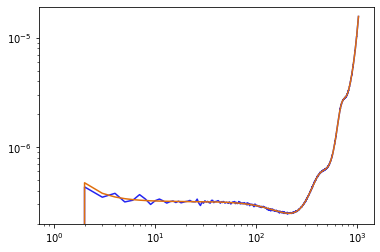

In [25]:
loglog(l,n0bs)
loglog(L,Ag)

In [26]:
l, n0bs_c = np.loadtxt(qobj['c'].f['EB'].n0bs,unpack=True,usecols=(0,1))

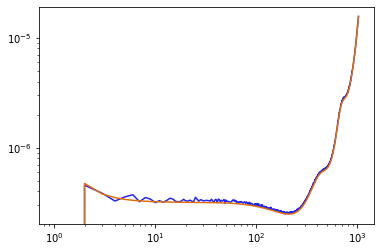

In [31]:
loglog(l,n0bs_c)
loglog(L,Ag)

In [32]:
bc, mcb, vcb = np.loadtxt(qobj['v'].f['EB'].mcls,unpack=True,usecols=(0,1,5))

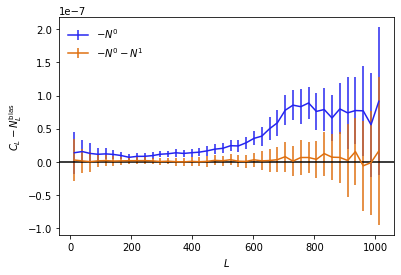

In [33]:
bias0 = binning.binning(n0bs+Lfac*ucl_read['pp'],mb)
bias1 = binning.binning(n0bs_c+Lfac*ucl_read['pp'],mb)
xlabel(r'$L$')
ylabel(r'$C_L-N_L^{\rm bias}$')
errorbar(mb.bc,mcb-bias0,yerr=vcb,label=r'$-N^0$')
errorbar(mb.bc,mcb-bias1,yerr=vcb,label=r'$-N^0-N^1$')
axhline(0,color='k')
legend(loc=2)